# Análisis de Datos Energéticos
## Análisis de Voltaje y Corriente

Este notebook analiza las lecturas de voltaje y corriente del sistema de monitoreo de energía.

### 1. Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurar estilos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('Librerías importadas correctamente')

Librerías importadas correctamente


### 2. Cargar datos

In [2]:
# Buscar archivos CSV en la carpeta de datos
data_dir = Path('data/sessions')
csv_files = list(data_dir.glob('*.csv'))

print(f'Archivos encontrados: {len(csv_files)}')
for file in csv_files:
    print(f'  - {file.name}')

# Cargar todos los datos
dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    print(f'\n{file.name}: {len(df)} registros cargados')
    dfs.append(df)

# Combinar todos los datos
df = pd.concat(dfs, ignore_index=True)
print(f'\nTotal de registros: {len(df)}')

Archivos encontrados: 1
  - 2026-07-20_14-22-13.csv



2026-07-20_14-22-13.csv: 967 registros cargados

Total de registros: 967


### 3. Exploración inicial de datos

In [3]:
# Ver primeras filas
print('Primeras filas del dataset:')
print(df.head(10))

print('\nÚltimas filas del dataset:')
print(df.tail(10))

print('\nTipo de datos:')
print(df.dtypes)

print('\nInformación general:')
print(df.info())

Primeras filas del dataset:
             timestamp  hour  voltage  current  power  temperature  humidity
0  2026-07-20 14:22:15    14     0.00      0.0    0.0         30.4      71.8
1  2026-07-20 14:22:16    14     0.00      0.0    0.0         30.4      71.8
2  2026-07-20 14:22:18    14     0.00      0.0    0.0         30.6      71.9
3  2026-07-20 14:22:19    14     0.00      0.0    0.0         30.6      71.9
4  2026-07-20 14:22:20    14     0.00      0.0    0.0         30.6      71.9
5  2026-07-20 14:22:21    14    37.39      0.0    0.0         30.6      71.9
6  2026-07-20 14:22:22    14   113.33      0.0    0.0         30.6      71.9
7  2026-07-20 14:22:23    14   113.34      0.0    0.0         30.6      71.9
8  2026-07-20 14:22:25    14   113.89      0.0    0.0         30.6      71.8
9  2026-07-20 14:22:26    14   114.17      0.0    0.0         30.6      71.8

Últimas filas del dataset:
               timestamp  hour  voltage  current  power  temperature  humidity
957  2026-07-20 14

<class 'pandas.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    967 non-null    str    
 1   hour         967 non-null    int64  
 2   voltage      967 non-null    float64
 3   current      967 non-null    float64
 4   power        967 non-null    float64
 5   temperature  967 non-null    float64
 6   humidity     967 non-null    float64
dtypes: float64(5), int64(1), str(1)
memory usage: 53.0 KB
None


### 4. Estadísticas descriptivas

In [4]:
print('Estadísticas descriptivas de Voltaje y Corriente:')
print(df[['voltage', 'current']].describe())

Estadísticas descriptivas de Voltaje y Corriente:


          voltage     current
count  967.000000  967.000000
mean   117.295936    0.647796
std      9.062485    0.341606
min      0.000000    0.000000
25%    116.785000    0.808000
50%    118.000000    0.822000
75%    119.320000    0.831000
max    134.670000    1.601000


### 5. Análisis de Promedios

In [5]:
# Calcular promedios generales
voltage_promedio = df['voltage'].mean()
corriente_promedio = df['current'].mean()

print('═' * 50)
print('PROMEDIOS GENERALES')
print('═' * 50)
print(f'Voltaje Promedio:  {voltage_promedio:.2f} V')
print(f'Corriente Promedio: {corriente_promedio:.3f} A')
print('═' * 50)

# Estadísticas adicionales
print('\nESTADÍSTICAS ADICIONALES - VOLTAJE:')
print(f'  Mínimo:  {df["voltage"].min():.2f} V')
print(f'  Máximo:  {df["voltage"].max():.2f} V')
print(f'  Mediana: {df["voltage"].median():.2f} V')
print(f'  Desv.Est: {df["voltage"].std():.2f} V')

print('\nESTADÍSTICAS ADICIONALES - CORRIENTE:')
print(f'  Mínimo:  {df["current"].min():.3f} A')
print(f'  Máximo:  {df["current"].max():.3f} A')
print(f'  Mediana: {df["current"].median():.3f} A')
print(f'  Desv.Est: {df["current"].std():.3f} A')

══════════════════════════════════════════════════
PROMEDIOS GENERALES
══════════════════════════════════════════════════
Voltaje Promedio:  117.30 V
Corriente Promedio: 0.648 A
══════════════════════════════════════════════════

ESTADÍSTICAS ADICIONALES - VOLTAJE:
  Mínimo:  0.00 V
  Máximo:  134.67 V
  Mediana: 118.00 V
  Desv.Est: 9.06 V

ESTADÍSTICAS ADICIONALES - CORRIENTE:
  Mínimo:  0.000 A
  Máximo:  1.601 A
  Mediana: 0.822 A
  Desv.Est: 0.342 A


### 6. Análisis por hora

In [6]:
# Promedios por hora
promedio_por_hora = df.groupby('hour')[['voltage', 'current']].mean()

print('Promedios de Voltaje y Corriente por Hora:')
print(promedio_por_hora.round(3))

# Hora con mayor y menor voltaje
hora_max_volt = promedio_por_hora['voltage'].idxmax()
hora_min_volt = promedio_por_hora['voltage'].idxmin()

print(f'\nHora con mayor voltaje promedio: {hora_max_volt}:00 ({promedio_por_hora.loc[hora_max_volt, "voltage"]:.2f} V)')
print(f'Hora con menor voltaje promedio: {hora_min_volt}:00 ({promedio_por_hora.loc[hora_min_volt, "voltage"]:.2f} V)')

# Hora con mayor y menor corriente
hora_max_corr = promedio_por_hora['current'].idxmax()
hora_min_corr = promedio_por_hora['current'].idxmin()

print(f'\nHora con mayor corriente promedio: {hora_max_corr}:00 ({promedio_por_hora.loc[hora_max_corr, "current"]:.3f} A)')
print(f'Hora con menor corriente promedio: {hora_min_corr}:00 ({promedio_por_hora.loc[hora_min_corr, "current"]:.3f} A)')

Promedios de Voltaje y Corriente por Hora:
      voltage  current
hour                  
14    117.296    0.648

Hora con mayor voltaje promedio: 14:00 (117.30 V)
Hora con menor voltaje promedio: 14:00 (117.30 V)

Hora con mayor corriente promedio: 14:00 (0.648 A)
Hora con menor corriente promedio: 14:00 (0.648 A)


### 7. Visualizaciones

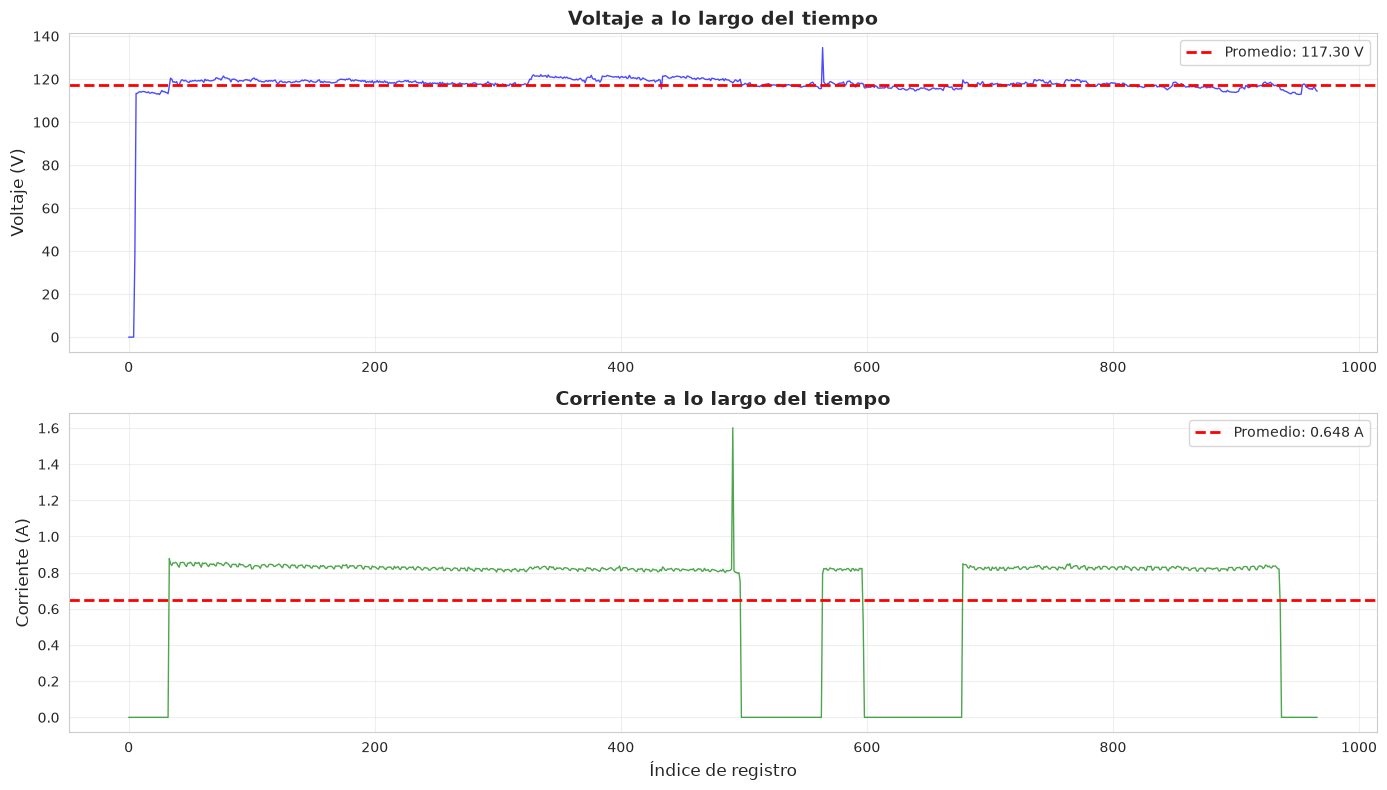

Gráfico guardado como: voltaje_corriente_tiempo.png


In [7]:
# Gráfico de línea: Voltaje y Corriente a lo largo del tiempo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

ax1.plot(df.index, df['voltage'], linewidth=1, alpha=0.7, color='blue')
ax1.axhline(voltage_promedio, color='red', linestyle='--', linewidth=2, label=f'Promedio: {voltage_promedio:.2f} V')
ax1.set_title('Voltaje a lo largo del tiempo', fontsize=14, fontweight='bold')
ax1.set_ylabel('Voltaje (V)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df.index, df['current'], linewidth=1, alpha=0.7, color='green')
ax2.axhline(corriente_promedio, color='red', linestyle='--', linewidth=2, label=f'Promedio: {corriente_promedio:.3f} A')
ax2.set_title('Corriente a lo largo del tiempo', fontsize=14, fontweight='bold')
ax2.set_ylabel('Corriente (A)', fontsize=12)
ax2.set_xlabel('Índice de registro', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('voltaje_corriente_tiempo.png', dpi=300, bbox_inches='tight')
plt.show()
print('Gráfico guardado como: voltaje_corriente_tiempo.png')

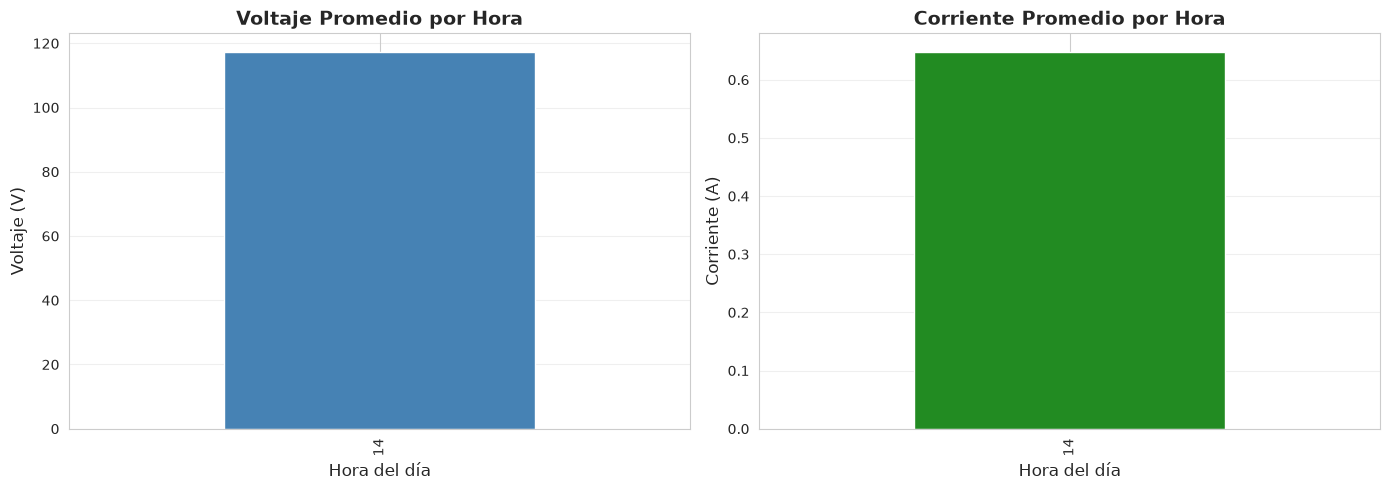

Gráfico guardado como: promedios_por_hora.png


In [8]:
# Gráfico de barras: Promedios por hora
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

promedio_por_hora['voltage'].plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Voltaje Promedio por Hora', fontsize=14, fontweight='bold')
ax1.set_ylabel('Voltaje (V)', fontsize=12)
ax1.set_xlabel('Hora del día', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')

promedio_por_hora['current'].plot(kind='bar', ax=ax2, color='forestgreen')
ax2.set_title('Corriente Promedio por Hora', fontsize=14, fontweight='bold')
ax2.set_ylabel('Corriente (A)', fontsize=12)
ax2.set_xlabel('Hora del día', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('promedios_por_hora.png', dpi=300, bbox_inches='tight')
plt.show()
print('Gráfico guardado como: promedios_por_hora.png')

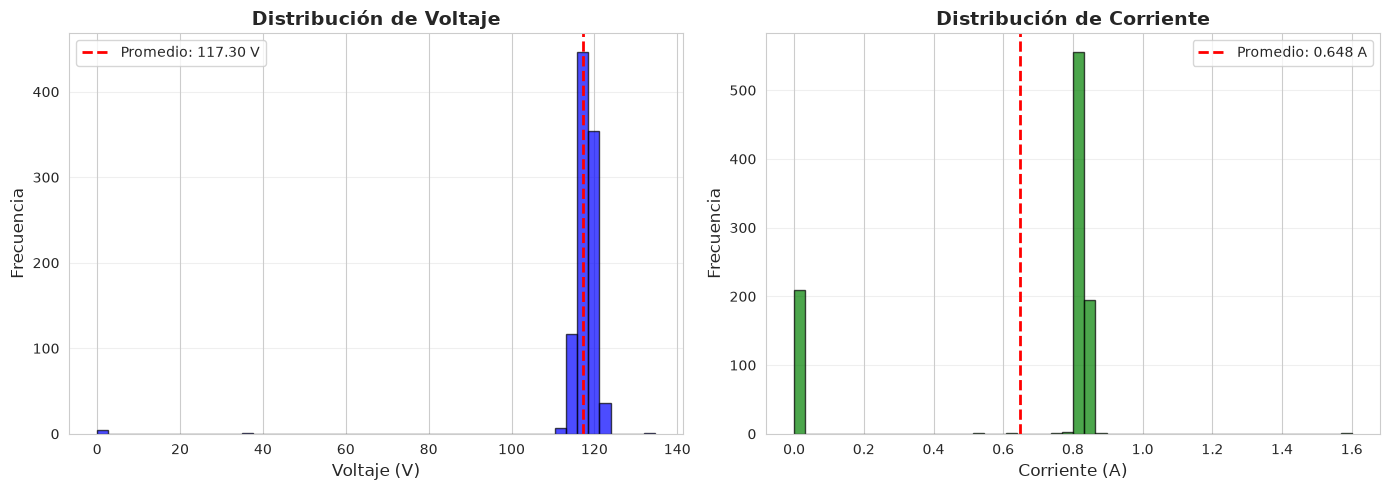

Gráfico guardado como: distribucion_voltaje_corriente.png


In [9]:
# Histogramas de distribución
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(df['voltage'], bins=50, color='blue', alpha=0.7, edgecolor='black')
ax1.axvline(voltage_promedio, color='red', linestyle='--', linewidth=2, label=f'Promedio: {voltage_promedio:.2f} V')
ax1.set_title('Distribución de Voltaje', fontsize=14, fontweight='bold')
ax1.set_xlabel('Voltaje (V)', fontsize=12)
ax1.set_ylabel('Frecuencia', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

ax2.hist(df['current'], bins=50, color='green', alpha=0.7, edgecolor='black')
ax2.axvline(corriente_promedio, color='red', linestyle='--', linewidth=2, label=f'Promedio: {corriente_promedio:.3f} A')
ax2.set_title('Distribución de Corriente', fontsize=14, fontweight='bold')
ax2.set_xlabel('Corriente (A)', fontsize=12)
ax2.set_ylabel('Frecuencia', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('distribucion_voltaje_corriente.png', dpi=300, bbox_inches='tight')
plt.show()
print('Gráfico guardado como: distribucion_voltaje_corriente.png')

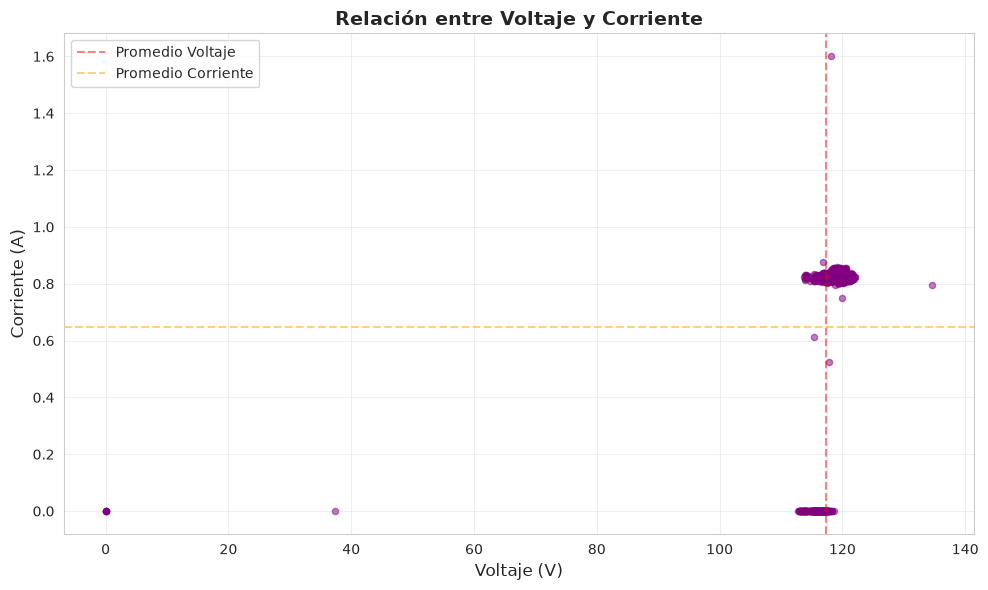

Gráfico guardado como: voltaje_vs_corriente.png


In [10]:
# Gráfico de dispersión: Voltaje vs Corriente
plt.figure(figsize=(10, 6))
plt.scatter(df['voltage'], df['current'], alpha=0.5, s=20, color='purple')
plt.xlabel('Voltaje (V)', fontsize=12)
plt.ylabel('Corriente (A)', fontsize=12)
plt.title('Relación entre Voltaje y Corriente', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axvline(voltage_promedio, color='red', linestyle='--', alpha=0.5, label='Promedio Voltaje')
plt.axhline(corriente_promedio, color='orange', linestyle='--', alpha=0.5, label='Promedio Corriente')
plt.legend()
plt.tight_layout()
plt.savefig('voltaje_vs_corriente.png', dpi=300, bbox_inches='tight')
plt.show()
print('Gráfico guardado como: voltaje_vs_corriente.png')

### 8. Resumen y Conclusiones

In [11]:
print('\n' + '═' * 60)
print('RESUMEN DEL ANÁLISIS')
print('═' * 60)
print(f'Total de registros analizados: {len(df):,}')
print(f'Rango de fechas: {df["timestamp"].min()} a {df["timestamp"].max()}')
print(f'\nVOLTAJE:')
print(f'  Promedio: {voltage_promedio:.2f} V')
print(f'  Rango: {df["voltage"].min():.2f} - {df["voltage"].max():.2f} V')
print(f'  Variación: {(df["voltage"].max() - df["voltage"].min()):.2f} V')
print(f'\nCORRIENTE:')
print(f'  Promedio: {corriente_promedio:.3f} A')
print(f'  Rango: {df["current"].min():.3f} - {df["current"].max():.3f} A')
print(f'  Variación: {(df["current"].max() - df["current"].min()):.3f} A')
print('═' * 60)


════════════════════════════════════════════════════════════
RESUMEN DEL ANÁLISIS
════════════════════════════════════════════════════════════
Total de registros analizados: 967
Rango de fechas: 2026-07-20 14:22:15 a 2026-07-20 14:40:51

VOLTAJE:
  Promedio: 117.30 V
  Rango: 0.00 - 134.67 V
  Variación: 134.67 V

CORRIENTE:
  Promedio: 0.648 A
  Rango: 0.000 - 1.601 A
  Variación: 1.601 A
════════════════════════════════════════════════════════════
